# Phase 3 Failures — Analysis

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

from analysis.aggregate import load_runs
from analysis.plots import plot_recovery_modes, plot_fault_latency, plot_latency_distribution
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = load_runs("../../artifacts/", prefix="failures")
print(f"Loaded {len(df)} Phase 3 runs")
display(df.describe())

Loaded 20 Phase 3 runs


,total_latency_s,total_prompt_tokens,total_completion_tokens,step_trace_len,message_count,state_size_bytes,recovery_time_s,output_quality
count,20.000000,20.0,20.0,20.000000,5.0,5.0,20.000000,20.000000
mean,10.206456,0.0,0.0,0.500000,0.0,0.0,0.000572,0.250000
std,16.435327,0.0,0.0,0.888523,0.0,0.0,0.000227,0.444262
min,0.001855,0.0,0.0,0.000000,0.0,0.0,0.000281,0.000000
25%,0.002939,0.0,0.0,0.000000,0.0,0.0,0.000357,0.000000
50%,1.504086,0.0,0.0,0.000000,0.0,0.0,0.000504,0.000000
75%,10.978903,0.0,0.0,0.500000,0.0,0.0,0.000799,0.250000
max,40.264925,0.0,0.0,2.000000,0.0,0.0,0.000915,1.000000


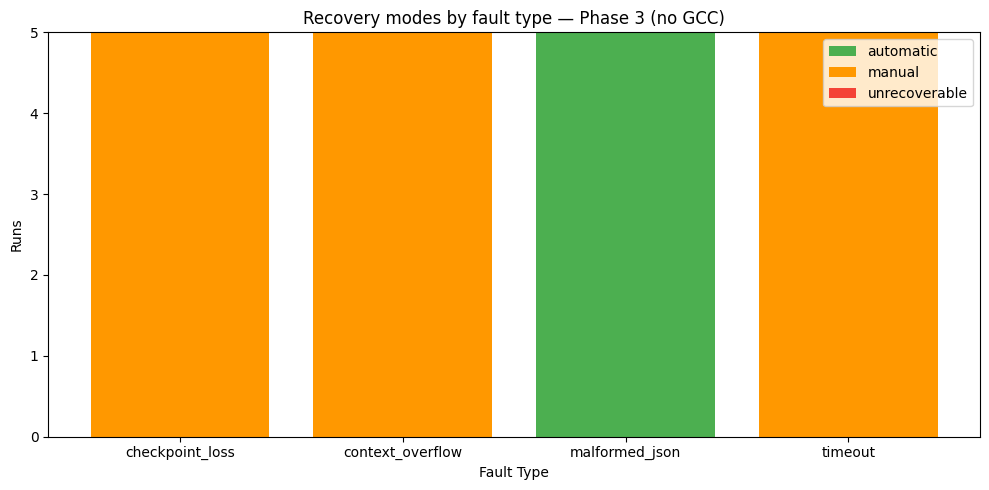

In [2]:
# Recovery modes by fault type
fig = plot_recovery_modes(df, label="Phase 3 (no GCC)")
plt.show()

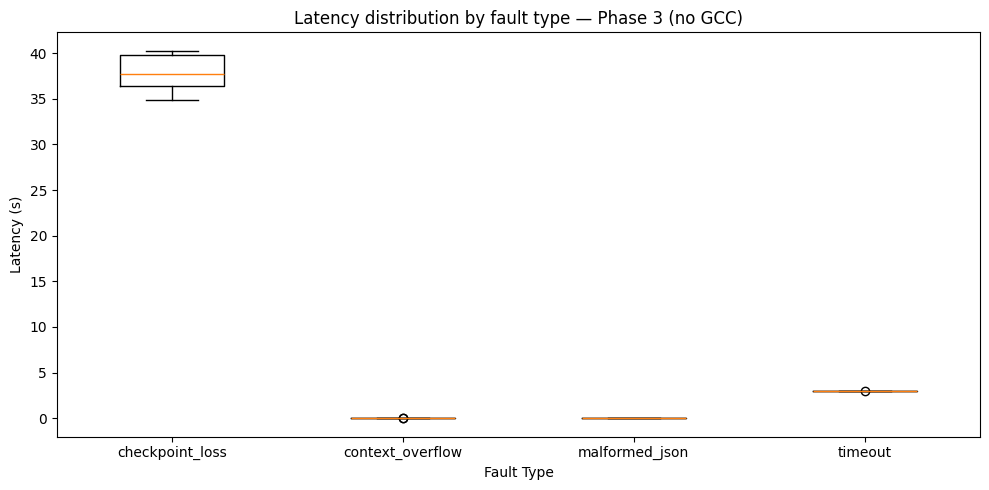

In [3]:
# Latency distribution by fault type
fig = plot_fault_latency(df, label="Phase 3 (no GCC)")
plt.show()

In [4]:
# Detailed summary table
summary = df.groupby("failure_type").agg(
    runs=("run_id", "count"),
    automatic=("recovery_mode", lambda x: (x == "automatic").sum()),
    manual=("recovery_mode", lambda x: (x == "manual").sum()),
    avg_latency_s=("total_latency_s", "mean"),
    std_latency_s=("total_latency_s", "std"),
    avg_output_quality=("output_quality", "mean"),
).round(3)
display(summary)

,runs,automatic,manual,avg_latency_s,std_latency_s,avg_output_quality
failure_type,,,,,,
checkpoint_loss,5,0,5,37.816,2.259,1.0
context_overflow,5,0,5,0.003,0.001,0.0
malformed_json,5,5,0,0.002,0.000,0.0
timeout,5,0,5,3.004,0.002,0.0


## Observations

### Recovery Mode Results
- **timeout**: manual — `AgentTimeoutError` propagates to runner; crew never completes
- **malformed_json**: automatic — `JSONDecodeError` caught by `crew_node`'s `except Exception`; graph reaches END with error stored in state
- **checkpoint_loss**: manual — crew completes and writes files, but `CheckpointLostError` raised before state update reaches LangGraph. Demonstrates checkpoint asymmetry.
- **context_overflow**: manual — token pre-check fires before crew runs

### Key Finding: State Model Incompatibility
The three state models (LangGraph typed state, CrewAI role memory, filesystem) diverge silently.
`checkpoint_loss` proves this: output files exist on disk but LangGraph has no record. Recovery
requires human restart because CrewAI cannot resume mid-task — it's all-or-nothing.

### Notes for Phase 4
- All injectors are LLM-call-free, so GCC latency should only affect `checkpoint_loss` (which runs the full crew)
- The TPM rate cap (60k) is unlikely to trigger with small workspace data
- Primary question: does GCC latency compound with fault latency enough to make any failure unrecoverable?